## SU Decomposition Example

### Introduction
This notebook contains some numerical examples of the SU-decomposition applied to rigid body motion trajectory data. Specifically, the temporal profile of the corresponding U matrix is computed and visualized.

In this notebook, the available trajectory data types are:
1. synthetic data of a helical translation, a rotation about a fixed axis, and a precession motion;
2. real data from a recording of a human-demonstrated pouring motion. 

 
You can change the value for the regularization parameter L used within the SU-decomposition algorithm. Based on your specified value for L, the notebook provides a comparison of the unregularized U matrix versus the regularized U matrix.

### Running the code

##### 1. Import python libraries and add the data folder to the python path

In [1]:
import pathlib
import sys

parent_folder = str(pathlib.Path().cwd().parent)
sys.path.append(parent_folder)

path_to_data = rf"{parent_folder}/data"
path_to_figures = rf"{parent_folder}/figures"

##### 2. Specify the type of input trajectory (*'pouring', 'helical_translation', 'axis_rotation', and 'precession' are supported*)

In [2]:
input_trajectory = "pouring"

##### 3. Load and visualize the trajectory data

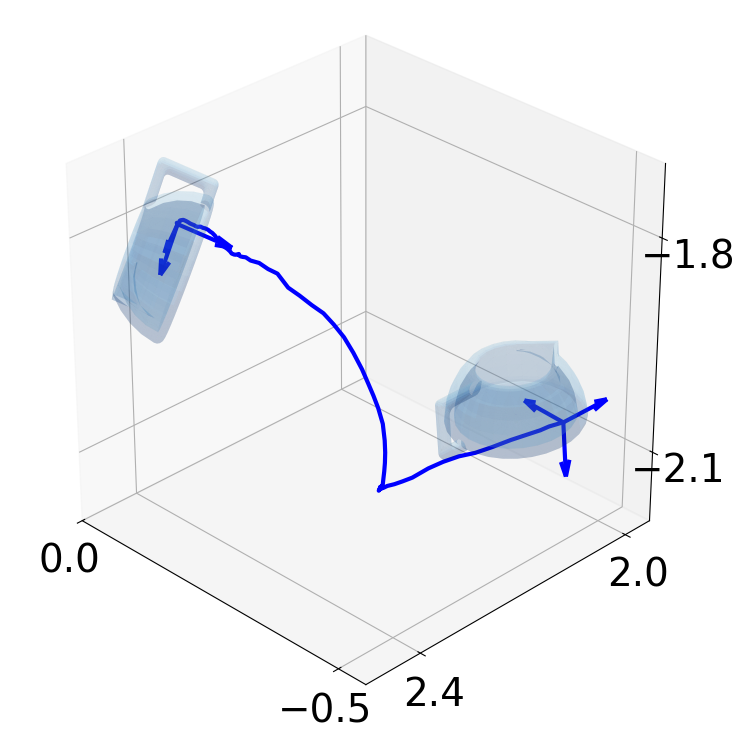

In [3]:
import matplotlib.pyplot as plt

import sulib.data_handling as dh
import sulib.plotting as plotting

# Load the trajectory data
T, N, dt = dh.load_demo_trajectory_motion(input_trajectory, path_to_data)
total_time = (N - 1) * dt

# Subsample raw trajectory data
T, ds = T[:, :, 0:N:3], 3 * dt
N = T.shape[2]

# Load data of the rigid body for visualization
object_data = dh.load_object_data(input_trajectory, path_to_data)

# Plot the trajectory
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")
key_values_body_frame, key_values_rigid_object = [0, -1], [0, -1]
ax = plotting.plot_trajectory_origin(ax, T, color="b", linewidth=3.0)
ax = plotting.plot_frames(ax, T, key_values_body_frame, color="b", linewidth=3.0, arrow_len=0.08)
ax = plotting.plot_rigid_bodies(ax, T, key_values_rigid_object, object_data)
ax = plotting.ax_settings_general(ax)
if input_trajectory == "pouring":
    ax = plotting.ax_settings_pouring_trajectory(ax)
fig.savefig(rf"{path_to_figures}/input_trajectory.svg")

##### 4. Specify a value for the regularization parameter L (expressed in meters)

In [4]:
L = 0.3

##### 5. Calculate the DUTIR using the SU decomposition

In [5]:
import sulib.su_decomp as su_decomp

# Calculate dutir without regularization
dutir, _ = su_decomp.compute_dutir_from_pose_traj(T, dt)

# Calculate dutir with regularization
dutir_reg, _ = su_decomp.compute_dutir_from_pose_traj(T, dt, L)

##### 6. Visualize the computed DUTIR (red = unregularized, blue = regularized)

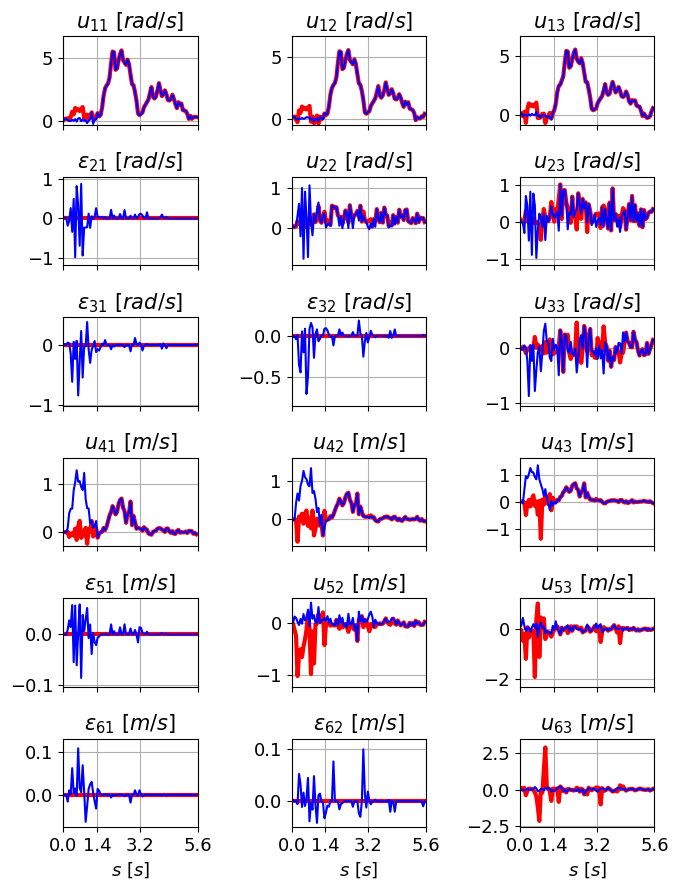

In [6]:
import sulib.plotting as plotting

fig, axes = plotting.initialize_plot_dutir("time", input_trajectory)
axes = plotting.plot_dutir(axes, dutir, total_time, color="r", linewidth=3.0)
axes = plotting.plot_dutir(axes, dutir_reg, total_time, color="b", linewidth=1.5)
fig.savefig(rf"{path_to_figures}/dutir_notebook.svg")